In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
wine = load_wine()

X = wine.data              # 13 features
y = wine.target            # class labels
print(X.shape)  # (178, 13)
print(y.shape)  # (178,)
feature_names = wine.feature_names
#Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(178, 13)
(178,)


In [ ]:
#Full PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
variance_ratio = pca_full.explained_variance_ratio_

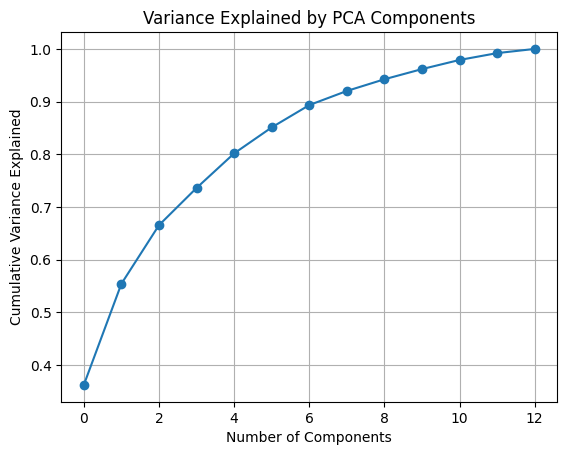

Variance Ratio Per Component:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

--- Variance Explained (Actual) ---
PC1: 36.20%
PC2: 19.21%
PC3: 11.12%

Total Variance (First 3 PCs): 66.53%


In [11]:
plt.figure()
plt.plot(np.cumsum(variance_ratio), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Variance Explained by PCA Components")
plt.grid()
plt.show()

print("Variance Ratio Per Component:")
print(variance_ratio)
print("\n--- Variance Explained (Actual) ---")
for i in range(3):
    print(f"PC{i+1}: {variance_ratio[i]*100:.2f}%")

print(f"\nTotal Variance (First 3 PCs): {np.sum(variance_ratio[:3])*100:.2f}%")


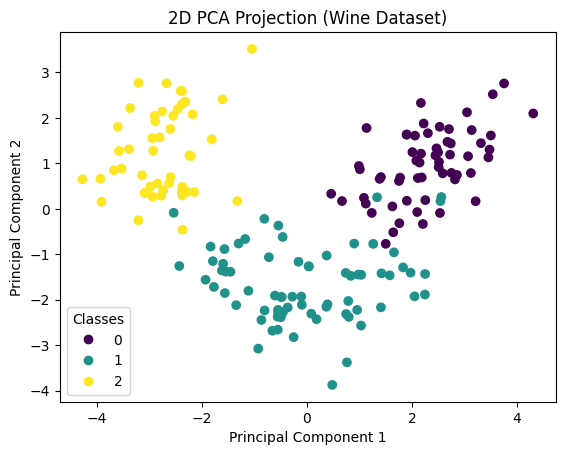

In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
plt.figure()
scatter = plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection (Wine Dataset)")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.show()

In [12]:
import plotly.express as px
from sklearn.decomposition import PCA

# PCA
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

# Create DataFrame for Plotly
import pandas as pd

df_pca = pd.DataFrame(
    X_pca_3,
    columns=["PC1", "PC2", "PC3"]
)
df_pca["Class"] = y

# Interactive 3D Plot
fig = px.scatter_3d(
    df_pca,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Class",
    title="Interactive 3D PCA Projection (Wine Dataset)"
)

fig.show()
